# TP3: CLASIFICANDO DE INFORMALES EN LA EPH
## Taller de Programación - UBA
## Grupo 4
---

In [ ]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 6.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=3d82cfffa21e3b1dd5a0fdaa397f03262cd3f2e24a5f5cf76dc3f8bf876292d0
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
import pandas as pd
import numpy as np
import os

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

ruta_proyecto = "/content/drive/MyDrive/Taller de Programación '26"
ruta_bases_tp2 = os.path.join(ruta_proyecto, "bases_TP2")

Mounted at /content/drive


### Levanto las bases generadas en el TP2

In [ ]:
base_final_limpia = pd.read_pickle(os.path.join(ruta_bases_tp2, "base_final_limpia.pkl"))
respondieron = pd.read_pickle(os.path.join(ruta_bases_tp2, "respondieron.pkl"))
ocupados_total = pd.read_pickle(os.path.join(ruta_bases_tp2, "ocupados_total.pkl"))
ocupados = pd.read_pickle(os.path.join(ruta_bases_tp2, "ocupados.pkl"))

print("Bases cargadas correctamente:")
print(f"base_final_limpia: {base_final_limpia.shape}")
print(f"respondieron:      {respondieron.shape}")
print(f"ocupados_total:    {ocupados_total.shape}")
print(f"ocupados:          {ocupados.shape}")

Bases cargadas correctamente:
base_final_limpia: (90563, 31)
respondieron:      (90442, 63)
ocupados_total:    (40830, 63)
ocupados:          (11411, 67)


### A. Enfoque de validación: 2024 como entrenamiento, 2025 como testeo

#### Separación de la base *ocupados*

In [ ]:
# Identificadores necesarios para vincular individuos entre años
id_cols = ['CODUSU', 'NRO_HOGAR', 'COMPONENTE']

# Variable objetivo
target = 'informal'

# Dummies creadas en TP1
# Se omite una categoría de referencia cuando corresponde
variables_dummies = [
    # Sociodemográficas
    'mujer',
    'jefe_hogar',
    'conyuge_pareja',
    'hijo_hogar',
    'con_pareja',
    'tiene_cobertura_medica',

    # Categoría ocupacional
    # cuenta_propia queda como categoría de referencia
    'patron',

    # Sector
    # sector_formal queda como categoría de referencia
    'sector_informal',
    'sector_hogares',

    # Tamaño del establecimiento
    # hasta 5 personas queda como categoría de referencia
    'establecimiento_6_a_40_personas',
    'establecimiento_mas_40_personas',

    # Región
    # GBA queda como categoría de referencia
    'region_noroeste',
    'region_noreste',
    'region_cuyo',
    'region_pampeana',
    'region_patagonia'
]


# Variables numéricas
variables_numericas = [
    'CH06',           # edad
    'P21_2025T4',     # ingreso ocupación principal a precios comparables
    'edad2',          # creada en TP2
    'educ',           # creada en TP2
    'horastrabj',     # creada en TP2
    'nhogar'          # creada en TP2
]


variables_X = variables_dummies + variables_numericas

print("Cantidad de características X:", len(variables_X))
print(variables_X)

Cantidad de características X: 22
['mujer', 'jefe_hogar', 'conyuge_pareja', 'hijo_hogar', 'con_pareja', 'tiene_cobertura_medica', 'patron', 'sector_informal', 'sector_hogares', 'establecimiento_6_a_40_personas', 'establecimiento_mas_40_personas', 'region_noroeste', 'region_noreste', 'region_cuyo', 'region_pampeana', 'region_patagonia', 'CH06', 'P21_2025T4', 'edad2', 'educ', 'horastrabj', 'nhogar']


In [ ]:
ocupados_2024 = ocupados[ocupados['anio_base'] == 2024].copy()
ocupados_2025 = ocupados[ocupados['anio_base'] == 2025].copy()

print("Ocupados 2024:", ocupados_2024.shape)
print("Ocupados 2025:", ocupados_2025.shape)

Ocupados 2024: (5746, 67)
Ocupados 2025: (5665, 67)


In [ ]:
# Matrices de características X
ocupados_X_2024 = ocupados_2024[variables_X].copy()
ocupados_X_2025 = ocupados_2025[variables_X].copy()

# Vectores objetivo
y_2024 = ocupados_2024[target].astype(int).copy()
y_2025 = ocupados_2025[target].astype(int).copy()

y_2024.name = 'informal'
y_2025.name = 'informal'


print("ocupados_X_2024:", ocupados_X_2024.shape)
print("y_2024:", y_2024.shape)

print("ocupados_X_2025:", ocupados_X_2025.shape)
print("y_2025:", y_2025.shape)

ocupados_X_2024: (5746, 22)
y_2024: (5746,)
ocupados_X_2025: (5665, 22)
y_2025: (5665,)


In [ ]:
# Informalidad observada en 2024 para cada individuo
informalidad_2024 = ocupados_2024[id_cols + [target]].copy()

informalidad_2024 = informalidad_2024.rename(columns={target: 'informal_2024'})

In [ ]:
# Base 2025 con identificadores, X e informalidad observada en 2025
base_2025_MM = ocupados_2025[id_cols + variables_X + [target]].copy()

# Inner join: solamente permanecen individuos presentes
# tanto en 2024 como en 2025
base_2025_MM = base_2025_MM.merge(
    informalidad_2024,
    on=id_cols,
    how='inner',
    validate='one_to_one'
)

print("Observaciones 2025 antes del join:", len(ocupados_2025))
print("Observaciones presentes en 2024 y 2025:", len(base_2025_MM))
print("Porcentaje recuperado:",round(len(base_2025_MM) / len(ocupados_2025) * 100, 2),"%"
)

Observaciones 2025 antes del join: 5665
Observaciones presentes en 2024 y 2025: 1564
Porcentaje recuperado: 27.61 %


In [ ]:
# y observado en 2025 para la muestra MM
y_2025_MM = base_2025_MM[target].astype(int).copy()
y_2025_MM.name = 'informal'

# Matriz X de 2025 para especificación Maurizio & Monsalvo
ocupados_X_2025_MM = base_2025_MM[ variables_X + ['informal_2024']].copy()

print("\nocupados_X_2025_MM:", ocupados_X_2025_MM.shape)
print("y_2025_MM:", y_2025_MM.shape)

display(ocupados_X_2025_MM.head())


ocupados_X_2025_MM: (1564, 23)
y_2025_MM: (1564,)


,mujer,jefe_hogar,conyuge_pareja,hijo_hogar,con_pareja,tiene_cobertura_medica,patron,sector_informal,sector_hogares,establecimiento_6_a_40_personas,...,region_cuyo,region_pampeana,region_patagonia,CH06,P21_2025T4,edad2,educ,horastrabj,nhogar,informal_2024
0,0,0,1,0,1,1,0,0,0,0,...,0,1,0,34,NaN,1156.0,8,36.0,4,1
1,1,0,0,1,0,0,0,1,0,0,...,0,1,0,45,400000.0,2025.0,9,0.0,3,1
2,0,1,0,0,0,1,1,0,0,1,...,0,0,0,62,2000000.0,3844.0,7,44.0,4,1
3,0,1,0,0,1,1,1,0,0,0,...,0,0,0,53,1900000.0,2809.0,17,40.0,4,0
4,0,0,1,0,1,1,0,0,0,0,...,0,1,0,43,1250000.0,1849.0,12,44.0,4,1


Control de como quedan las bases

In [ ]:
print(f"X 2024:     {ocupados_X_2024.shape}")
print(f"y 2024:     {y_2024.shape}")

print(f"X 2025:     {ocupados_X_2025.shape}")
print(f"y 2025:     {y_2025.shape}")

print(f"X 2025 MM:  {ocupados_X_2025_MM.shape}")
print(f"y 2025 MM:  {y_2025_MM.shape}")

print("\nDistribución y_2024:")
print(y_2024.value_counts(normalize=True).round(4))

print("\nDistribución y_2025:")
print(y_2025.value_counts(normalize=True).round(4))

print("\nDistribución y_2025_MM:")
print(y_2025_MM.value_counts(normalize=True).round(4))

X 2024:     (5746, 22)
y 2024:     (5746,)
X 2025:     (5665, 22)
y 2025:     (5665,)
X 2025 MM:  (1564, 23)
y 2025 MM:  (1564,)

Distribución y_2024:
informal
1    0.8082
0    0.1918
Name: proportion, dtype: float64

Distribución y_2025:
informal
1    0.8143
0    0.1857
Name: proportion, dtype: float64

Distribución y_2025_MM:
informal
1    0.7839
0    0.2161
Name: proportion, dtype: float64


#### Tabla de la diferencia de medias

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
resultados_balance = []

for variable in variables_X:

    x_2024 = ocupados_X_2024[variable].dropna()
    x_2025 = ocupados_X_2025[variable].dropna()

    media_2024 = x_2024.mean()
    media_2025 = x_2025.mean()

    # Diferencia: Test - Train
    diferencia = media_2025 - media_2024

    # Test t de Welch
    test = ttest_ind(
        x_2024,
        x_2025,
        equal_var=False,
        nan_policy='omit'
    )

    # Diferencia estandarizada de medias
    sd_pool = np.sqrt(
        (x_2024.var(ddof=1) + x_2025.var(ddof=1)) / 2
    )

    if sd_pool > 0:
        diferencia_estandarizada = diferencia / sd_pool
    else:
        diferencia_estandarizada = np.nan

    resultados_balance.append({
        'Variable': variable,
        'Media 2024': media_2024,
        'Media 2025': media_2025,
        'Diferencia': diferencia,
        'Dif. estandarizada': diferencia_estandarizada,
        'p-value': test.pvalue
    })


tabla_balance = pd.DataFrame(resultados_balance)


# Significancia estadística
def significancia(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.10:
        return '*'
    else:
        return ''


tabla_balance['Significancia'] = (
    tabla_balance['p-value'].apply(significancia)
)


# Tabla para presentar
tabla_balance_mostrar = tabla_balance.copy()

columnas_redondear = [
    'Media 2024',
    'Media 2025',
    'Diferencia',
    'Dif. estandarizada'
]

tabla_balance_mostrar[columnas_redondear] = (
    tabla_balance_mostrar[columnas_redondear].round(3)
)

tabla_balance_mostrar['p-value'] = (
    tabla_balance_mostrar['p-value'].round(4)
)


display(tabla_balance_mostrar)

print("*** p < 0.01 | ** p < 0.05 | * p < 0.10")

,Variable,Media 2024,Media 2025,Diferencia,Dif. estandarizada,p-value,Significancia
0,mujer,0.395,0.410,0.015,0.031,0.1024,
1,jefe_hogar,0.532,0.527,-0.004,-0.009,0.6379,
2,conyuge_pareja,0.238,0.242,0.004,0.010,0.5773,
3,hijo_hogar,0.178,0.180,0.001,0.003,0.8547,
4,con_pareja,0.589,0.590,0.001,0.002,0.8973,
5,tiene_cobertura_medica,0.549,0.535,-0.013,-0.027,0.1513,
6,patron,0.132,0.127,-0.004,-0.013,0.4770,
7,sector_informal,0.602,0.624,0.022,0.045,0.0171,**
8,sector_hogares,0.000,0.000,0.000,NaN,NaN,
9,establecimiento_6_a_40_personas,0.030,0.029,-0.001,-0.005,0.7849,


*** p < 0.01 | ** p < 0.05 | * p < 0.10


Se observan diferencias estadísticamente significativas entre 2024 y 2025 en algunas características, particularmente sector informal, región pampeana, ingreso, educación y horas trabajadas. Sin embargo, las diferencias estandarizadas son reducidas y se mantienen por debajo de 0,10, por lo que no se observan cambios sustanciales en la composición de las muestras de entrenamiento y testeo.

### B. Modelo de Regresión Logística: Extensión el trabajo de Maurizio & Monsalvo (2021)

#### Estimación y Efectos Marginales

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from ISLP import load_data

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# metricas de desempeño de clasificiacion
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
#from sklearn.metrics import plot_roc_curve

from sklearn.metrics import  auc


In [ ]:
bases = {
    "ocupados_X_2024": ocupados_X_2024,
    "y_2024": y_2024,
    "ocupados_X_2025_MM": ocupados_X_2025_MM,
    "y_2025_MM": y_2025_MM
}

for nombre, base in bases.items():
    print(f"\n--- {nombre} ---")
    print("Cantidad de NaN:", base.isna().sum().sum())
    print("Tiene NaN:", base.isna().any().any())





--- ocupados_X_2024 ---
Cantidad de NaN: 2609
Tiene NaN: True

--- y_2024 ---
Cantidad de NaN: 0
Tiene NaN: False

--- ocupados_X_2025_MM ---
Cantidad de NaN: 695
Tiene NaN: True

--- y_2025_MM ---
Cantidad de NaN: 0
Tiene NaN: False


In [ ]:
for nombre, base in bases.items():
    print(f"\n=== {nombre} ===")

    # Si es DataFrame o Series
    if hasattr(base, 'isna'):
        pct_nulos = (base.isna().mean() * 100).round(2)
        pct_filtrados = pct_nulos[pct_nulos > 0]

        if len(pct_filtrados) > 0:
            print("Porcentaje de NaNs por columna:")
            print(pct_filtrados.astype(str) + "%")
        else:
            print(" Base 100% limpia")


=== ocupados_X_2024 ===
Porcentaje de NaNs por columna:
tiene_cobertura_medica              0.16%
sector_informal                     0.28%
sector_hogares                      0.28%
establecimiento_6_a_40_personas     1.01%
establecimiento_mas_40_personas     1.01%
P21_2025T4                         26.11%
educ                                1.04%
horastrabj                         15.52%
dtype: object

=== y_2024 ===
 Base 100% limpia

=== ocupados_X_2025_MM ===
Porcentaje de NaNs por columna:
tiene_cobertura_medica              0.38%
sector_informal                     0.19%
sector_hogares                      0.19%
establecimiento_6_a_40_personas     1.09%
establecimiento_mas_40_personas     1.09%
P21_2025T4                         24.49%
educ                                1.34%
horastrabj                         15.66%
dtype: object

=== y_2025_MM ===
 Base 100% limpia


Las regresiones no se pueden hacer cuando hay variables sin datos. Hay que hacer algo con esto. Proponemos asignar valores en base a K Vecinos cercanos. Primero lo hacemos para 2025 y despues para 2024.

In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# 1. Definimos la lista exacta de tus variables con NaN
cols_con_nan = [
    'tiene_cobertura_medica',
    'sector_informal',
    'sector_hogares',
    'establecimiento_6_a_40_personas',
    'establecimiento_mas_40_personas',
    'P21_2025T4',
    'educ',
    'horastrabj'
]

# 3. Seleccionamos las columnas numéricas que servirán para calcular las distancias
# Recomendado: Incluir las cols con NaN + otras columnas limpias que aporten contexto (ej. edad, sexo)
cols_para_knn = ocupados_X_2025_MM.select_dtypes(include=['number']).columns

# 4. Inicializamos Escalador e Imputador (k=5 es el estándar habitual)
scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=5)

# 5. Paso A: Escalamos los datos
# StandardScaler conserva los NaNs mientras estandariza
datos_escalados = scaler.fit_transform(ocupados_X_2025_MM[cols_para_knn])

# 6. Paso B: Imputamos los NaNs con KNN
datos_imputados_escalados = imputer.fit_transform(datos_escalados)

# 7. Paso C: Des-escalamos para volver a la escala original (pesos, horas, etc.)
datos_imputados = scaler.inverse_transform(datos_imputados_escalados)

# 8. Reasignamos al DataFrame
ocupados_X_2025_MM[cols_para_knn] = datos_imputados

# 9. Verificación final
print("NaNs restantes en las variables seleccionadas de 2025:")
print(ocupados_X_2025_MM[cols_con_nan].isna().sum())

NaNs restantes en las variables seleccionadas de 2025:
tiene_cobertura_medica             0
sector_informal                    0
sector_hogares                     0
establecimiento_6_a_40_personas    0
establecimiento_mas_40_personas    0
P21_2025T4                         0
educ                               0
horastrabj                         0
dtype: int64


In [ ]:
cols_para_knn = ocupados_X_2024.select_dtypes(include=['number']).columns

# 4. Inicializamos Escalador e Imputador (k=5 es el estándar habitual)
scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=5)

# 5. Paso A: Escalamos los datos
# StandardScaler conserva los NaNs mientras estandariza
datos_escalados = scaler.fit_transform(ocupados_X_2024[cols_para_knn])

# 6. Paso B: Imputamos los NaNs con KNN
datos_imputados_escalados = imputer.fit_transform(datos_escalados)

# 7. Paso C: Des-escalamos para volver a la escala original (pesos, horas, etc.)
datos_imputados = scaler.inverse_transform(datos_imputados_escalados)

# 8. Reasignamos al DataFrame
ocupados_X_2024[cols_para_knn] = datos_imputados

# 9. Verificación final
print("NaNs restantes en las variables seleccionadas de 2024:")
print(ocupados_X_2024[cols_con_nan].isna().sum())

NaNs restantes en las variables seleccionadas de 2024:
tiene_cobertura_medica             0
sector_informal                    0
sector_hogares                     0
establecimiento_6_a_40_personas    0
establecimiento_mas_40_personas    0
P21_2025T4                         0
educ                               0
horastrabj                         0
dtype: int64


In [ ]:
# ============================================================
# Corrección de variables binarias luego de la imputación KNN
# ============================================================

# KNN puede imputar valores intermedios (0.2, 0.4, 0.6, etc.)
# en variables que originalmente son binarias.
# Las devolvemos a formato 0/1.

for var in variables_dummies:

    if var in ocupados_X_2024.columns:
        ocupados_X_2024[var] = (
            ocupados_X_2024[var]
            .round()
            .astype(int)
        )

    if var in ocupados_X_2025_MM.columns:
        ocupados_X_2025_MM[var] = (
            ocupados_X_2025_MM[var]
            .round()
            .astype(int)
        )

# informal_2024 también debe permanecer binaria
ocupados_X_2025_MM['informal_2024'] = (
    ocupados_X_2025_MM['informal_2024']
    .round()
    .astype(int)
)

# Verificación
print("Valores posibles en las dummies 2024:")
for var in variables_dummies:
    if var in ocupados_X_2024.columns:
        print(var, ocupados_X_2024[var].unique())

print("\nValores posibles en las dummies 2025-MM:")
for var in variables_dummies:
    if var in ocupados_X_2025_MM.columns:
        print(var, ocupados_X_2025_MM[var].unique())

Valores posibles en las dummies 2024:
mujer [1 0]
jefe_hogar [1 0]
conyuge_pareja [0 1]
hijo_hogar [0 1]
con_pareja [0 1]
tiene_cobertura_medica [1 0]
patron [0 1]
sector_informal [1 0]
sector_hogares [0]
establecimiento_6_a_40_personas [0 1]
establecimiento_mas_40_personas [0 1]
region_noroeste [0 1]
region_noreste [0 1]
region_cuyo [0 1]
region_pampeana [1 0]
region_patagonia [0 1]

Valores posibles en las dummies 2025-MM:
mujer [0 1]
jefe_hogar [0 1]
conyuge_pareja [1 0]
hijo_hogar [0 1]
con_pareja [1 0]
tiene_cobertura_medica [1 0]
patron [0 1]
sector_informal [0 1]
sector_hogares [0]
establecimiento_6_a_40_personas [0 1]
establecimiento_mas_40_personas [0 1]
region_noroeste [0 1]
region_noreste [0 1]
region_cuyo [0 1]
region_pampeana [1 0]
region_patagonia [0 1]


Chequeamos si hay alguna varibale con colinealidad.

In [ ]:
def diagnosticar_singularidad(X, nombre):
    print(f"\n=== {nombre} ===")

    # 1. Columnas con varianza cero (constantes) — muy común en submuestras chicas
    #    como ocupados_X_2025_MM, donde alguna dummy puede quedar toda en 0
    constantes = X.columns[X.nunique() <= 1]
    if len(constantes) > 0:
        print("Columnas constantes (varianza cero):", list(constantes))
    else:
        print("Sin columnas constantes")

    # 2. Colinealidad perfecta o cuasi-perfecta entre pares de columnas
    corr = X.corr().abs()
    np.fill_diagonal(corr.values, 0)
    pares_altos = corr[corr > 0.95].stack()
    if len(pares_altos) > 0:
        print("Pares con correlación > 0.95:")
        print(pares_altos)
    else:
        print("Sin pares altamente correlacionados")

    # 3. Rango de la matriz vs. cantidad de columnas (el chequeo más directo)
    rango = np.linalg.matrix_rank(X.values)
    print(f"Rango de la matriz: {rango} / {X.shape[1]} columnas")
    if rango < X.shape[1]:
        print("¡La matriz NO tiene rango completo! Hay dependencia lineal exacta entre columnas.")

diagnosticar_singularidad(ocupados_X_2024, "ocupados_X_2024_cleaned")
diagnosticar_singularidad(ocupados_X_2025_MM, "ocupados_X_2025_MM_cleaned")


=== ocupados_X_2024_cleaned ===
Columnas constantes (varianza cero): ['sector_hogares']
Pares con correlación > 0.95:
CH06   edad2    0.985897
edad2  CH06     0.985897
dtype: float64
Rango de la matriz: 21 / 22 columnas
¡La matriz NO tiene rango completo! Hay dependencia lineal exacta entre columnas.

=== ocupados_X_2025_MM_cleaned ===
Columnas constantes (varianza cero): ['sector_hogares']
Pares con correlación > 0.95:
CH06   edad2    0.987349
edad2  CH06     0.987349
dtype: float64
Rango de la matriz: 22 / 23 columnas
¡La matriz NO tiene rango completo! Hay dependencia lineal exacta entre columnas.


Sector_hogares es una variable binaria creada en el TP1 que identificaba aquellos trabajadores que trabajaban en el hogar. Como estamos trabajando con una base que filtra a la informalidad entre cuentapropistas y patrones, esta columna siempre es 0. Por lo que hay colinealidad perfecta con la columna de constantes. Eliminamos esta columna para seguir con la regresión.

In [ ]:
ocupados_X_2024 = ocupados_X_2024.drop(columns='sector_hogares')
ocupados_X_2025_MM = ocupados_X_2025_MM.drop(columns='sector_hogares')


Ahora si podemos hacer la regresión logistica.

In [ ]:
# Statsmodels necesita que agregues la columna de 1s a mano (sklearn lo hace internamente)
Xtrain_2024 = sm.add_constant(ocupados_X_2024)
Xtrain_2025_MM = sm.add_constant(ocupados_X_2025_MM)

# Ajuste de los dos modelos
logit_model_2024_sm = sm.Logit(y_2024, Xtrain_2024)
result_2024 = logit_model_2024_sm.fit()
print(result_2024.summary2())

logit_model_2025_sm = sm.Logit(y_2025_MM, Xtrain_2025_MM)
result_2025 = logit_model_2025_sm.fit()
print(result_2025.summary2())

Optimization terminated successfully.
         Current function value: 0.153340
         Iterations 9
                                  Results: Logit
Model:                     Logit                  Method:                 MLE      
Dependent Variable:        informal               Pseudo R-squared:       0.686    
Date:                      2026-08-16 10:23       AIC:                    1806.1883
No. Observations:          5746                   BIC:                    1952.6260
Df Model:                  21                     Log-Likelihood:         -881.09  
Df Residuals:              5724                   LL-Null:                -2808.7  
Converged:                 1.0000                 LLR p-value:            0.0000   
No. Iterations:            9.0000                 Scale:                  1.0000   
-----------------------------------------------------------------------------------
                                 Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
---------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Armado de tabla comparativa

In [ ]:
def armar_tabla_resultados(result, sufijo):
    coeficientes = result.params
    std_error = result.bse
    odds_ratio = np.exp(coeficientes)

    tabla = pd.DataFrame({
        'Variable': coeficientes.index,
        f'Coef {sufijo}': coeficientes.values,
        f'Std. Error {sufijo}': std_error.values,
        f'Odds Ratio {sufijo}': odds_ratio.values
    })

    return tabla

tabla_2024 = armar_tabla_resultados(result_2024, '2024')
tabla_2025_MM = armar_tabla_resultados(result_2025, '2025 MM')

# Outer join para conservar 'informal_2024', que solo existe en el modelo 2025 MM
tabla_comparativa = tabla_2024.merge(
    tabla_2025_MM,
    on='Variable',
    how='outer'
)

# Reordenamos: primero las variables que están en ambos modelos,
# 'informal_2024' al final para que se note que es la variable nueva
tabla_comparativa['en_ambos'] = tabla_comparativa['Coef 2024'].notna() & tabla_comparativa['Coef 2025 MM'].notna()
tabla_comparativa = tabla_comparativa.sort_values(
    by=['en_ambos', 'Variable'],
    ascending=[False, True]
).drop(columns='en_ambos').reset_index(drop=True)

tabla_comparativa.round(3)

,Variable,Coef 2024,Std. Error 2024,Odds Ratio 2024,Coef 2025 MM,Std. Error 2025 MM,Odds Ratio 2025 MM
0,CH06,-0.091,0.030,9.130000e-01,-0.012,0.093,9.880000e-01
1,P21_2025T4,-0.000,0.000,1.000000e+00,0.000,0.000,1.000000e+00
2,con_pareja,-0.149,0.179,8.620000e-01,0.936,0.482,2.550000e+00
3,const,21.883,1.085,3.189921e+09,23.647,3.349,1.861952e+10
4,conyuge_pareja,-0.409,0.353,6.640000e-01,-2.317,1.044,9.900000e-02
5,edad2,0.001,0.000,1.001000e+00,-0.000,0.001,1.000000e+00
6,educ,-1.226,0.045,2.940000e-01,-1.512,0.140,2.200000e-01
7,establecimiento_6_a_40_personas,-10.436,0.515,0.000000e+00,-18.536,1.943,0.000000e+00
8,establecimiento_mas_40_personas,-13.947,1.951,0.000000e+00,-36.278,40307.259,0.000000e+00
9,hijo_hogar,-0.415,0.340,6.600000e-01,-1.294,0.923,2.740000e-01


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Verificaciones de la estimación

In [ ]:
#Predicción sobre 2025-MM con el modelo estimado en 2024

# Variables utilizadas en el modelo 2024
variables_modelo_2024 = [
    var for var in result_2024.params.index
    if var != 'const'
]

# Tomamos de 2025-MM únicamente las variables presentes
# en el modelo estimado con 2024.
# informal_2024 no se incluye porque no formó parte de ese modelo.
X_2025_MM_modelo2024 = (
    ocupados_X_2025_MM[variables_modelo_2024]
    .copy()
)

# Agregamos constante
X_2025_MM_modelo2024 = sm.add_constant(
    X_2025_MM_modelo2024,
    has_constant='add'
)

# Mismo orden de columnas que durante la estimación
X_2025_MM_modelo2024 = (
    X_2025_MM_modelo2024[result_2024.params.index]
)

# Probabilidad predicha de informalidad en 2025
prob_pred_2025 = result_2024.predict(
    X_2025_MM_modelo2024
)

# Base para el gráfico
grafico_educ = pd.DataFrame({
    'educ': ocupados_X_2025_MM['educ'],
    'prob_informal': prob_pred_2025
})

display(grafico_educ.head())

,educ,prob_informal
0,8.0,0.999862
1,9.0,0.999460
2,7.0,0.983390
3,17.0,0.901348
4,12.0,0.974434


In [ ]:
variables_revision = [
    'establecimiento_6_a_40_personas',
    'establecimiento_mas_40_personas',
    'patron'
]

for var in variables_revision:
    print(f"\n--- {var} ---")
    display(
        pd.crosstab(
            ocupados_X_2025_MM[var].round(),
            y_2025_MM,
            margins=True
        )
    )


--- establecimiento_6_a_40_personas ---


informal,0,1,All
establecimiento_6_a_40_personas,,,
0,295,1224,1519
1,43,2,45
All,338,1226,1564



--- establecimiento_mas_40_personas ---


informal,0,1,All
establecimiento_mas_40_personas,,,
0,332,1226,1558
1,6,0,6
All,338,1226,1564



--- patron ---


informal,0,1,All
patron,,,
0,293,1063,1356
1,45,163,208
All,338,1226,1564


La categoría de establecimientos de más de 40 personas presenta solo seis observaciones en la muestra MM, todas correspondientes a trabajadores formales, generando separación perfecta y problemas de convergencia. Por este motivo, su coeficiente no se interpreta y los resultados del modelo MM deben considerarse con cautela.

#### Visualización

Predicción sobre datos 2025-MM usando coeficientes estimados con el modelo de 2024

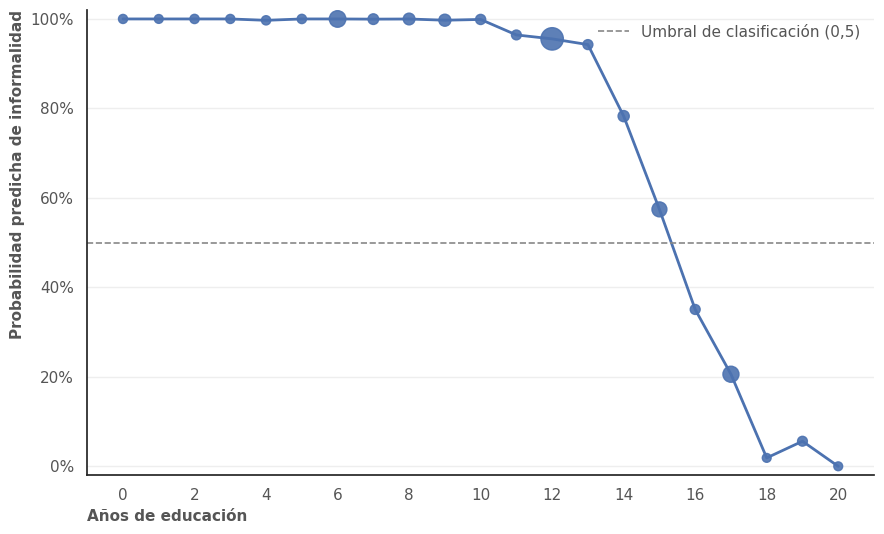

In [ ]:
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#eeeeee",
    "axes.axisbelow": True
})

tamano_puntos = 40 + 220 * (
    prob_educ['n'] / prob_educ['n'].max()
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(
    prob_educ['educ_redondeada'],
    prob_educ['prob_media'],
    linewidth=2
)

ax.scatter(
    prob_educ['educ_redondeada'],
    prob_educ['prob_media'],
    s=tamano_puntos,
    alpha=0.9
)

ax.axhline(
    y=0.5,
    linestyle='--',
    linewidth=1.2,
    color='#888888',
    label='Umbral de clasificación (0,5)'
)

ax.set_xlabel('Años de educación', fontsize=11, color='#555555', fontweight='bold', loc='left')
ax.set_ylabel('Probabilidad predicha de informalidad', fontsize=11, color='#555555', fontweight='bold', loc='top')

ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.set_ylim(-0.02, 1.02)

ax.set_xticks(
    range(
        prob_educ['educ_redondeada'].min(),
        prob_educ['educ_redondeada'].max() + 1,
        2
    )
)
ax.tick_params(colors='#555555')

ax.grid(axis='x', visible=False)

ax.legend(loc='upper right', frameon=False, labelcolor='#555555')

plt.tight_layout()
plt.show()

### C. Desempeño del modelo y predicción afuera de la muestra

#### Matriz de confusión

Para permitir una comparación homogénea entre ambos modelos, evaluamos su desempeño sobre la muestra común de individuos observados en 2024 y 2025 (ocupados_X_2025_MM). De esta forma, ambas predicciones se comparan contra el mismo vector observado y_2025_MM.

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score,
    auc
)

In [ ]:
#Modelo 2024
prob_2024 = prob_pred_2025.copy()

# Convertimos las probabilidades en predicciones 0/1 usando el umbral de 0.5
y_pred_2024 = np.where(
    prob_2024 > 0.50,
    1,
    0
)

print('Proporción de informales predichos:', y_pred_2024.mean().round(3))
print('Proporción de informales reales:',y_2025_MM.astype(int).mean().round(3))

# Matriz de confusión
cm_2024 = confusion_matrix(
    y_2025_MM,
    y_pred_2024
)

print("\nMatriz de confusión - Modelo 2024")
print(cm_2024)

Proporción de informales predichos: 0.801
Proporción de informales reales: 0.784

Matriz de confusión - Modelo 2024
[[ 272   66]
 [  40 1186]]


In [ ]:
tabla_cm_2024 = pd.DataFrame(
    cm_2024,
    index=['Real: Formal', 'Real: Informal'],
    columns=['Predicho: Formal', 'Predicho: Informal']
)

display(tabla_cm_2024)


,Predicho: Formal,Predicho: Informal
Real: Formal,272,66
Real: Informal,40,1186


In [ ]:
# Modelo MM

# Probabilidades predichas
prob_MM = result_2025.predict(Xtrain_2025_MM)

# Clasificación usando umbral 0.5
y_pred_MM = np.where(
    prob_MM > 0.50,
    1,
    0
)

print('Proporción de informales predichos:',y_pred_MM.mean().round(3))

print('Proporción de informales reales:', y_2025_MM.astype(int).mean().round(3))

# Matriz de confusión
cm_MM = confusion_matrix(
    y_2025_MM,
    y_pred_MM
)

print("\nMatriz de confusión - Modelo MM")
print(cm_MM)

Proporción de informales predichos: 0.788
Proporción de informales reales: 0.784

Matriz de confusión - Modelo MM
[[ 307   31]
 [  24 1202]]


In [ ]:
tabla_cm_MM = pd.DataFrame(
    cm_MM,
    index=['Real: Formal', 'Real: Informal'],
    columns=['Predicho: Formal', 'Predicho: Informal']
)

display(tabla_cm_MM)

,Predicho: Formal,Predicho: Informal
Real: Formal,307,31
Real: Informal,24,1202


#### Métricas de desempeño

In [ ]:
def calcular_metricas(y_true, y_pred, y_prob):

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Tasa de Verdadero Positivo (Sensibilidad / Recall)
    tpr = tp / (tp + fn)

    # Tasa de Falso Positivo
    fpr = fp / (fp + tn)

    # Área bajo la curva ROC
    auc_score = roc_auc_score(y_true, y_prob)

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    return tpr, fpr, auc_score, accuracy

In [ ]:
# Modelo estimado con 2024
tpr_2024, fpr_2024_bayes, auc_2024, acc_2024 = calcular_metricas(
    y_2025_MM,
    y_pred_2024,
    prob_2024
)

# Modelo MM
tpr_MM, fpr_MM_bayes, auc_MM, acc_MM = calcular_metricas(
    y_2025_MM,
    y_pred_MM,
    prob_MM
)

Tabla comparativa

In [ ]:
tabla_metricas = pd.DataFrame({
    'Métrica': [
        'Tasa Verdadero Positivo (Sensibilidad)',
        'Tasa Falso Positivo',
        'AUC',
        'Accuracy'
    ],

    'Modelo 2024': [
        round(tpr_2024, 3),
        round(fpr_2024_bayes, 3),
        round(auc_2024, 3),
        round(acc_2024, 3)
    ],

    'Modelo MM': [
        round(tpr_MM, 3),
        round(fpr_MM_bayes, 3),
        round(auc_MM, 3),
        round(acc_MM, 3)
    ]
})

display(tabla_metricas)

,Métrica,Modelo 2024,Modelo MM
0,Tasa Verdadero Positivo (Sensibilidad),0.967,0.980
1,Tasa Falso Positivo,0.195,0.092
2,AUC,0.983,0.991
3,Accuracy,0.932,0.965


#### Curva ROC

In [ ]:
# Modelo 2024
fpr_roc_2024, tpr_roc_2024, _ = roc_curve(
    y_2025_MM,
    prob_2024
)

roc_auc_2024 = auc(
    fpr_roc_2024,
    tpr_roc_2024
)

# Modelo MM
fpr_roc_MM, tpr_roc_MM, _ = roc_curve(
    y_2025_MM,
    prob_MM
)

roc_auc_MM = auc(
    fpr_roc_MM,
    tpr_roc_MM
)

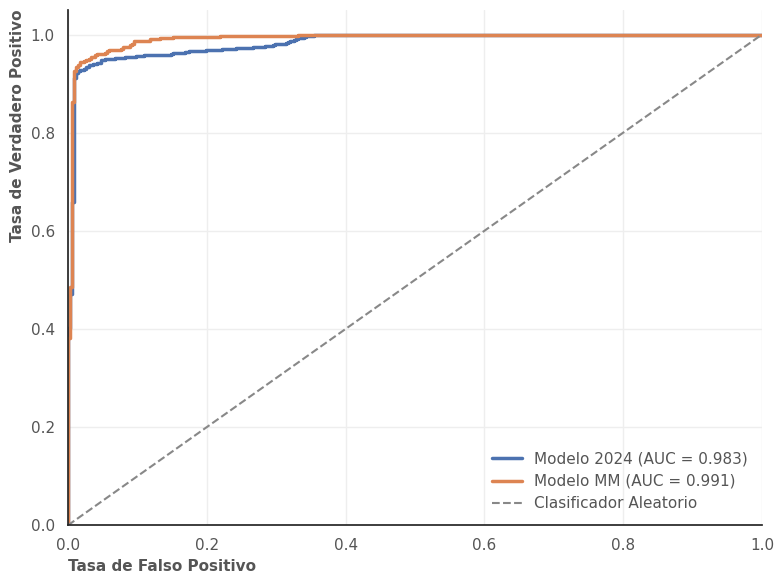

In [ ]:
sns.set_theme(style="white", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#eeeeee",
    "axes.axisbelow": True
})

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_roc_2024, tpr_roc_2024,
    lw=2.5,
    label=f'Modelo 2024 (AUC = {roc_auc_2024:.3f})'
)

plt.plot(
    fpr_roc_MM, tpr_roc_MM,
    lw=2.5,
    label=f'Modelo MM (AUC = {roc_auc_MM:.3f})'
)

plt.plot(
    [0, 1], [0, 1],
    lw=1.5, color='#888888', linestyle='--',
    label='Clasificador Aleatorio'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('Tasa de Falso Positivo', fontsize=11, color='#555555', fontweight='bold', loc='left')
plt.ylabel('Tasa de Verdadero Positivo', fontsize=11, color='#555555', fontweight='bold', loc='top')
plt.xticks(color='#555555')
plt.yticks(color='#555555')

plt.legend(loc='lower right', frameon=False, labelcolor='#555555')

plt.tight_layout()
plt.show()